In [1]:
import numpy as np
from gfapy import Gfa
import networkx as nx

In [2]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit_aer import AerSimulator
from qiskit.circuit import Parameter

In [3]:
from qiskit import transpile

In [4]:
from scipy.linalg import block_diag

In [5]:
def get_nz_at_savepoint(circuit, data, name):
    sv = np.array(data[name])
    sv[np.abs(sv) < 1e-12] = 0
    nz = np.nonzero(sv)[0]
    for i in range(len(nz)):
        print(np.binary_repr(nz[i], circuit.num_qubits))

    print(sv[nz])

In [6]:
gfa = Gfa("H	VN:Z:1.0\n\
S	u0	TAAC	LN:i:4	SC:f:1.0\n\
S	u1	CCCG	LN:i:4	SC:f:1.0\n\
L	u0	+	u1	+	0M	EC:i:1\n\
L	u1	-	u0	-	0M	EC:i:1")

In [7]:
gfa.segments

[gfapy.Line('S	u0	TAAC	LN:i:4	SC:f:1.0',version='gfa1',vlevel=1),
 gfapy.Line('S	u1	CCCG	LN:i:4	SC:f:1.0',version='gfa1',vlevel=1)]

In [8]:
n = 2
K = 2
T = 2
ceil_log2_K1 = int(np.ceil(np.log2(K+1)))
ceil_log_n2 = int(np.ceil(np.log2(n+2)))
ceil_log_n1 = int(np.ceil(np.log2(n+1)))

In [9]:
graph = nx.Graph()

for segment_line in gfa.segments:
    graph.add_node(segment_line.name, weight=segment_line.SC)

graph.add_node('end')

for segment_line in gfa.segments:
    graph.add_edges_from([(segment_line.name, 'end')])
for edge_line in gfa.edges:
    graph.add_edges_from([
        (edge_line.sid1.name, edge_line.sid2.name),
    ])

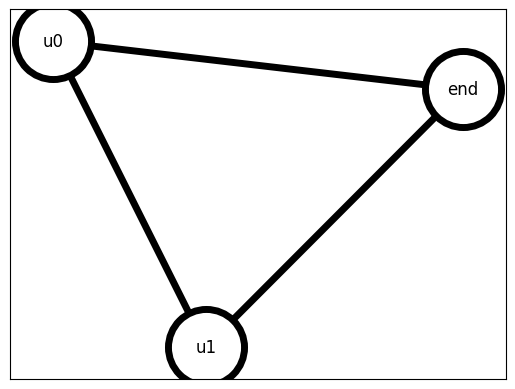

In [10]:
options = {
    "font_size": 12,
    "node_size": 3000,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 5,
    "width": 5,
}
nx.draw_networkx(graph, nx.spring_layout(graph), **options)


In [11]:
sim = AerSimulator()

In [12]:
def is_equal_to(num_qubits: int, value):
    circ = QuantumCircuit(num_qubits + 1)
    bin_value = [int(x) for x in np.binary_repr(value, num_qubits)]
    for idx, b in enumerate(bin_value):
        if b == 0:
            circ.x(idx)
    
    circ.mcx(list(range(num_qubits)), num_qubits)
    for idx, b in enumerate(bin_value):
        if b == 0:
            circ.x(idx)
    return circ

In [13]:
is_equal_circ = is_equal_to(ceil_log_n2, 1)
is_equal_circ.draw()

┌───┐     ┌───┐
q_0: ┤ X ├──■──┤ X ├
     └───┘  │  └───┘
q_1: ───────■───────
          ┌─┴─┐     
q_2: ─────┤ X ├─────
          └───┘

In [15]:
def controlled_copy_with_swap(num_qubits, K):
    circ = QuantumCircuit((K+1) * num_qubits + 1 + 1)
    # C_copy_Flag, To be copied, list(reg_to_be_copied_into, spare_registers), swap_spare_registers_flag
    circ.x((K+1) * num_qubits + 1)

    for i in range(num_qubits+1, 2*num_qubits+1):
        circ.x(i)
    circ.mcx(list(range(num_qubits+1, 2*num_qubits+1)), (K+1) * num_qubits + 1)

    for i in range(num_qubits+1, 2*num_qubits+1):
        circ.x(i)
    for i in range(num_qubits):
        top = K * num_qubits + i + 1
        for idx in range(top, 1+num_qubits+i, -1):
            circ.cswap((K+1) * num_qubits + 1, idx, idx-1)
            
    circ.x((K+1) * num_qubits + 1)
    for i in range(num_qubits+1, 2*num_qubits+1):
        circ.x(i)
    circ.mcx(list(range(num_qubits+1, 2*num_qubits+1)), (K+1) * num_qubits + 1)
    for i in range(num_qubits+1, 2*num_qubits+1):
        circ.x(i)

    for i in range(num_qubits):
        circ.mcx([0, i + 1], num_qubits + i + 1)
    return circ

In [16]:
cc_circ = controlled_copy_with_swap(2, 3)
cc_circ.draw()

q_0: ───────────────────────────────────────────────────────■────■──
                                                            │    │  
q_1: ───────────────────────────────────────────────────────■────┼──
                                                            │    │  
q_2: ───────────────────────────────────────────────────────┼────■──
     ┌───┐     ┌───┐         ┌───┐                   ┌───┐┌─┴─┐  │  
q_3: ┤ X ├──■──┤ X ├───────X─┤ X ├────────────────■──┤ X ├┤ X ├──┼──
     ├───┤  │  ├───┤       │ └───┘         ┌───┐  │  ├───┤└───┘┌─┴─┐
q_4: ┤ X ├──■──┤ X ├────X──X─────────────X─┤ X ├──■──┤ X ├─────┤ X ├
     └───┘  │  └───┘    │  │             │ └───┘  │  └───┘     └───┘
q_5: ───────┼────────X──X──┼──────────X──X────────┼─────────────────
            │        │  │  │          │  │        │                 
q_6: ───────┼────X───X──┼──┼───────X──X──┼────────┼─────────────────
            │    │   │  │  │       │  │  │        │                 
q_7: ───────┼────X───┼──┼──┼───X───X──┼──┼────────┼─────────────────
            │    │   │  │  │   │   │  │  │        │                 
q_8: ───────┼────┼───┼──┼──┼───X───┼──┼──┼────────┼─────────────────
     ┌───┐┌─┴─┐  │   │  │  │   │   │  │  │ ┌───┐┌─┴─┐               
q_9: ┤ X ├┤ X ├──■───■──■──■───■───■──■──■─┤ X ├┤ X ├───────────────
     └───┘└───┘                            └───┘└───┘

In [17]:
def compute_next_nodes(circuit: QuantumCircuit, registers, j):
    cc_circ = controlled_copy_with_swap(ceil_log_n2, K)
    is_equal_circ = is_equal_to(ceil_log_n2, j)
    for t in range(T-1):
        circuit.barrier(label=f'is_equal c_{t}, {j}')
        circuit.compose(
            is_equal_circ, 
            list(range(circuit.find_bit(registers[f'solution_{t}'][0]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                + [circuit.find_bit(registers[f'is_equal_flag_{t}'][0]).index],
            inplace=True
        )

        circuit.barrier(label=f'c_copy c_{t+1} -> next node list')
        is_equal_flag = circuit.find_bit(registers[f'is_equal_flag_{t}'][0]).index
        to_copy = list(range(
            circuit.find_bit(registers[f'solution_{t+1}'][0]).index, circuit.find_bit(registers[f'solution_{t+1}'][-1]).index + 1
        ))
        copy_registers = list(range(
            circuit.find_bit(registers['next_node_0'][0]).index, circuit.find_bit(registers[f'next_node_{K-1}'][-1]).index + 1
        ))
        next_node_flag = circuit.find_bit(registers['next_node_flag'][0]).index

        circuit.compose(
            cc_circ, 
            [is_equal_flag] + to_copy + copy_registers + [next_node_flag],
            inplace=True
        )

        circuit.barrier(label=f'uncompute is_equal c_{t}, {j}')
        circuit.compose(
            is_equal_circ, 
            list(range(circuit.find_bit(registers[f'solution_{t}'][0]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                + [circuit.find_bit(registers[f'is_equal_flag_{t}'][0]).index],
            inplace=True
        )
        circuit.barrier()
    return circuit

In [18]:
def uncompute_next_nodes(circuit: QuantumCircuit, registers, j):
    cc_circ = controlled_copy_with_swap(ceil_log_n2, K)
    is_equal_circ = is_equal_to(ceil_log_n2, j)
    for t in range(T-2, -1, -1):
        circuit.barrier(label=f'is_equal c_{t}, {j}')
        circuit.compose(
            is_equal_circ, 
            list(range(circuit.find_bit(registers[f'solution_{t}'][0]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                + [circuit.find_bit(registers[f'is_equal_flag_{t}'][0]).index],
            inplace=True
        )

        circuit.barrier(label=f'c_copy c_{t+1} -> next node list')
        is_equal_flag = circuit.find_bit(registers[f'is_equal_flag_{t}'][0]).index
        to_copy = list(range(
            circuit.find_bit(registers[f'solution_{t+1}'][0]).index, circuit.find_bit(registers[f'solution_{t+1}'][-1]).index + 1
        ))
        copy_registers = list(range(
            circuit.find_bit(registers['next_node_0'][0]).index, circuit.find_bit(registers[f'next_node_{K-1}'][-1]).index + 1
        ))
        next_node_flag = circuit.find_bit(registers['next_node_flag'][0]).index

        circuit.compose(
            cc_circ.reverse_ops(), 
            [is_equal_flag] + to_copy + copy_registers + [next_node_flag],
            inplace=True
        )

        circuit.barrier(label=f'uncompute is_equal c_{t}, {j}')
        circuit.compose(
            is_equal_circ, 
            list(range(circuit.find_bit(registers[f'solution_{t}'][0]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                + [circuit.find_bit(registers[f'is_equal_flag_{t}'][0]).index],
            inplace=True
        )
        circuit.barrier()
    return circuit

In [19]:
def penalise_graph_steps(circuit, registers, i, parameter):
    nodes = list(graph.nodes)
    for j in range(1, n+1):
        if (nodes[i-1], nodes[j-1]) not in graph.edges:
            is_equal_circ = is_equal_to(ceil_log_n2, j)
            circuit.barrier(label=f'penalty for {nodes[i-1], nodes[j-1]}')
            for k in range(K):
                circuit.compose(
                    is_equal_circ,
                    list(range(
                        circuit.find_bit(registers[f'next_node_{k}'][0]).index, circuit.find_bit(registers[f'next_node_{k}'][-1]).index + 1
                    )) + [circuit.find_bit(registers[f'constraint_rotate_flag_{k}'][0]).index],
                    inplace=True
                )
                circuit.p(
                    parameter, 
                    circuit.find_bit(registers[f'constraint_rotate_flag_{k}'][0]).index
                )
                circuit.compose(
                    is_equal_circ,
                    list(range(
                        circuit.find_bit(registers[f'next_node_{k}'][0]).index, circuit.find_bit(registers[f'next_node_{k}'][-1]).index + 1
                    )) + [circuit.find_bit(registers[f'constraint_rotate_flag_{k}'][0]).index],
                    inplace=True
                )
        circuit.barrier()

    return circuit

In [20]:
def penalise_graph_end_steps(circuit, registers, parameter):
    nodes = list(graph.nodes)
    for j in range(1, n+1):
        is_equal_circ = is_equal_to(ceil_log_n2, j)
        circuit.barrier(label=f'penalty for {nodes[-1], nodes[j-1]}')
        for k in range(K):
            circuit.compose(
                is_equal_circ,
                list(range(
                    circuit.find_bit(registers[f'next_node_{k}'][0]).index, circuit.find_bit(registers[f'next_node_{k}'][-1]).index + 1
                )) + [circuit.find_bit(registers[f'constraint_rotate_flag_{k}'][0]).index],
                inplace=True
            )
            circuit.p(
                parameter, 
                circuit.find_bit(registers[f'constraint_rotate_flag_{k}'][0]).index
            )
            circuit.compose(
                is_equal_circ,
                list(range(
                    circuit.find_bit(registers[f'next_node_{k}'][0]).index, circuit.find_bit(registers[f'next_node_{k}'][-1]).index + 1
                )) + [circuit.find_bit(registers[f'constraint_rotate_flag_{k}'][0]).index],
                inplace=True
            )
    return circuit

In [ ]:
def get_constraint_circuit(state_prep_circuit: QuantumCircuit | None = None, parameter=Parameter('theta_cons')):
    circuit = QuantumCircuit()


    registers = {f'solution_{t}' : QuantumRegister(ceil_log_n1, name=f'solution_{t}') for t in range(T)}
    registers.update({f'is_equal_flag_{t}': QuantumRegister(1, name=f'is_equal_flag_{t}') for t in range(T-1)})
    registers.update({f'next_node_{k}': QuantumRegister(ceil_log_n2, name=f'next_node_{k}') for k in range(K)})
    registers.update({'next_node_flag': QuantumRegister(1, name='next_node_flag')})
    registers.update({f'constraint_rotate_flag_{k}': QuantumRegister(1, name=f'constraint_rotate_flag_{k}') for k in range(K)})


    for register in registers.values():
        circuit.add_register(register)


    if state_prep_circuit is not None:
        circuit.compose(state_prep_circuit, list(range(T * ceil_log_n1)), inplace=True)

    for j in range(1, n+1):
        circuit = compute_next_nodes(circuit, registers, j)
        # circuit.save_statevector(label=f'after_compute_next_nodes_{j}')
        circuit = penalise_graph_steps(circuit, registers, j, parameter)
        # circuit.save_statevector(label=f'after_penalise_{j}')
        circuit = uncompute_next_nodes(circuit, registers, j)
        # circuit.save_statevector(label=f'after_uncompute_next_nodes_{j}')

    circuit = compute_next_nodes(circuit, registers, n+1)
    # circuit.save_statevector(label='after_compute_next_nodes_end')
    circuit = penalise_graph_end_steps(circuit, registers, parameter)
    # circuit.save_statevector(label='after_penalise_end')
    circuit = uncompute_next_nodes(circuit, registers, n+1)
    # circuit.save_statevector(label='after_uncompute_next_nodes_end')
    
            
    return circuit

In [22]:
state_prep = QuantumCircuit(T * ceil_log_n2)
state_prep.x(0)
state_prep.x(1)
# state_prep.h(1)
state_prep.x(2)
# state_prep.h(3)
constraint_circuit = get_constraint_circuit(state_prep_circuit=state_prep)
constraint_circuit.save_statevector()

In [23]:
run_job = sim.run(constraint_circuit.assign_parameters({p: np.pi/4 for p in constraint_circuit.parameters}))
result = run_job.result()

In [24]:
result.get_counts()

{np.str_('000000000111'): np.float64(1.0)}

In [25]:
# get_nz_at_savepoint(constraint_circuit, result.data(0), 'after_compute_next_nodes_end')

In [26]:
constraint_circuit.draw(fold=-1)

┌───┐ is_equal c_0, 1 ┌───┐     ┌───┐ c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 1 ┌───┐     ┌───┐ ░  penalty for ('u0', 'u0')                                                      ░  ░  is_equal c_0, 1 ┌───┐     ┌───┐ c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 1 ┌───┐     ┌───┐ ░  is_equal c_0, 2                 c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 2                 ░  ░  penalty for ('u1', 'u1')                                                      ░  is_equal c_0, 2                 c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 2                 ░  is_equal c_0, 3       c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 3       ░  penalty for ('end', 'u0')                                                      penalty for ('end', 'u1')                                                      is_equal c_0, 3       c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 3       ░  statevector 
            solution_0_0: ┤ X ├────────░────────┤ X ├──■──┤ X ├──────────────░──────────────────────────────────────────────────────────────────────────────────░─────────────┤ X ├──■──┤ X ├─░─────────────░──────────────────────────────────────────────────────────────────░──░─────────░────────┤ X ├──■──┤ X ├──────────────░──────────────────────────────────────────────────────────────────────────────────░─────────────┤ X ├──■──┤ X ├─░─────────░───────────────■─────────────────────░──────────────────────────────────────────────────────────────────────────────────░────────────────────■────────░──░─────────────░──────────────────────────────────────────────────────────────────░─────────░───────────────■─────────────────────░──────────────────────────────────────────────────────────────────────────────────░────────────────────■────────░─────────░──────────■────────────────░──────────────────────────────────────────────────────────────────────────────────░───────────────■───░──────────────░──────────────────────────────────────────────────────────────────────────────░─────────────────────────────────────────────────────────────────────────░──────────■────────────────░──────────────────────────────────────────────────────────────────────────────────░───────────────■───░───────░──────
                          ├───┤        ░        └───┘  │  └───┘              ░                                                                                  ░             └───┘  │  └───┘ ░             ░                                                                  ░  ░         ░        └───┘  │  └───┘              ░                                                                                  ░             └───┘  │  └───┘ ░         ░        ┌───┐  │  ┌───┐              ░                                                                                  ░             ┌───┐  │  ┌───┐ ░  ░             ░                                                                  ░         ░        ┌───┐  │  ┌───┐              ░                                                                                  ░             ┌───┐  │  ┌───┐ ░         ░          │                ░                                                                                  ░               │   ░              ░                                                                              ░                                                                         ░          │                ░                                                                                  ░               │   ░       ░      
            solution_0_1: ┤ X ├────────░───────────────■─────────────────────░─────────────────────────────────────────────────────────

In [27]:
def compute_count(circuit: QuantumCircuit, registers, j):
    is_equal_circ = is_equal_to(ceil_log_n2, j)

    add_one_matrix = np.diag(np.ones(2 ** ceil_log2_K1 - 1), -1)
    add_one_matrix[0, -1] = 1

    control_add_one = block_diag(np.eye(add_one_matrix.shape[0]), add_one_matrix)
    for t in range(T):
        circuit.compose(
            is_equal_circ, 
            list(range(circuit.find_bit(registers[f'solution_{t}'][0]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                + [circuit.find_bit(registers['flag'][0]).index],
            inplace=True
        )
        
        # circuit.save_statevector(f'before_c_add_{j}_{t}')
        circuit.unitary(
            control_add_one, 
            list(range(circuit.find_bit(registers['count'][-1]).index, circuit.find_bit(registers['count'][0]).index - 1, -1)) + \
                [circuit.find_bit(registers['flag'][0]).index],
            label='control-add-1'
        )
        # circuit.save_statevector(f'after_c_add_{j}_{t}')
        circuit.compose(
            is_equal_circ, 
            list(range(circuit.find_bit(registers[f'solution_{t}'][0]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                + [circuit.find_bit(registers['flag'][0]).index],
            inplace=True
        )
        
    return circuit

In [28]:
def penalise_count(circuit: QuantumCircuit, registers, j, parameter):
    nodes = list(graph.nodes)
    for i in range(K+1):
        if not graph.nodes[nodes[j-1]]["weight"] - i == 0:
            is_equal_circ = is_equal_to(ceil_log2_K1, i)


            circuit.compose(
                is_equal_circ,
                list(range(circuit.find_bit(registers['count'][0]).index, circuit.find_bit(registers['count'][-1]).index + 1)) \
                    + [circuit.find_bit(registers['count_rotate_flag'][0]).index],
                inplace=True
            )
            # circuit.save_statevector(label=f'before_p_{j}_{i}')
            circuit.p(parameter * (graph.nodes[nodes[j-1]]["weight"] - i) ** 2, circuit.find_bit(registers['count_rotate_flag'][0]).index)
            # circuit.save_statevector(label=f'after_p_{j}_{i}')

            circuit.compose(
                is_equal_circ,
                list(range(circuit.find_bit(registers['count'][0]).index, circuit.find_bit(registers['count'][-1]).index + 1)) \
                    + [circuit.find_bit(registers['count_rotate_flag'][0]).index],
                inplace=True
            )
    return circuit

In [29]:
def uncompute_count(circuit: QuantumCircuit, registers, j):
    is_equal_circ = is_equal_to(ceil_log_n2, j)

    minus_one_matrix = np.diag(np.ones(2 ** ceil_log2_K1 - 1), 1)
    minus_one_matrix[-1, 0] = 1
    control_minus_one = block_diag(np.eye(minus_one_matrix.shape[0]), minus_one_matrix)
    for t in range(T):
        circuit.compose(
            is_equal_circ, 
            list(range(circuit.find_bit(registers[f'solution_{t}'][0]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                + [circuit.find_bit(registers['flag'][0]).index],
            inplace=True
        )
        
        circuit.unitary(
            control_minus_one, 
            list(range(circuit.find_bit(registers['count'][-1]).index, circuit.find_bit(registers['count'][0]).index - 1, -1)) + \
                [circuit.find_bit(registers['flag'][0]).index],
            label='control-minus-1'
        )

        circuit.compose(
            is_equal_circ, 
            list(range(circuit.find_bit(registers[f'solution_{t}'][0]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                + [circuit.find_bit(registers['flag'][0]).index],
            inplace=True
        )
    return circuit

In [30]:
def get_objective_circuit(state_prep_circuit: QuantumCircuit | None = None, parameter=Parameter('theta_obj')):
    circuit = QuantumCircuit()


    registers = {f'solution_{t}' : QuantumRegister(ceil_log_n2, name=f'solution_{t}') for t in range(T)}
    registers.update({'flag': QuantumRegister(1, name='flag')})
    registers.update({'count': QuantumRegister(ceil_log2_K1, name='count')})
    registers.update({'count_rotate_flag': QuantumRegister(1, name='count_rotate_flag')})

    for register in registers.values():
        circuit.add_register(register)

    if state_prep_circuit is not None:
        circuit.compose(state_prep_circuit, list(range(T * ceil_log_n2)), inplace=True)

    for j in range(1, n+1):
        # circuit.save_statevector(label=f'before_count_{j}')
        circuit = compute_count(circuit, registers, j)
        # circuit.save_statevector(label=f'after_count_{j}')
        circuit.barrier()
        circuit = penalise_count(circuit, registers, j, parameter)
        # circuit.save_statevector(label=f'after_penalise_{j}')|
        circuit.barrier()
        circuit = uncompute_count(circuit, registers, j)
        # circuit.save_statevector(label=f'after_uncount_{j}')
        circuit.barrier()

    return circuit



In [31]:
state_prep = QuantumCircuit(T * ceil_log_n2)
state_prep.x(0)
state_prep.h(1)
state_prep.h(2)
state_prep.x(3)
objective_circuit = get_objective_circuit(state_prep_circuit=state_prep)
objective_circuit.save_statevector()

In [32]:
objective_circuit.draw(fold=-1)

┌───┐┌───┐           ┌───┐       ┌───┐     ┌───┐                                  ░                                                                                            ░ ┌───┐            ┌───┐        ┌───┐     ┌───┐                                    ░                                                                              ░                                                                                            ░                                                                                  ░  statevector 
     solution_0_0: ┤ X ├┤ X ├──■────────┤ X ├───────┤ X ├──■──┤ X ├──────────────────────────────────░────────────────────────────────────────────────────────────────────────────────────────────░─┤ X ├──■─────────┤ X ├────────┤ X ├──■──┤ X ├────────────────────────────────────░────────■───────────────────────────■─────────────────────────────────────────░────────────────────────────────────────────────────────────────────────────────────────────░────────■─────────────────────────────■───────────────────────────────────────────░───────░──────
                   ├───┤└───┘  │        └───┘       └───┘  │  └───┘                                  ░                                                                                            ░ └───┘  │         └───┘        └───┘  │  └───┘                                    ░ ┌───┐  │        ┌───┐       ┌───┐  │  ┌───┐                                  ░                                                                                            ░ ┌───┐  │         ┌───┐        ┌───┐  │  ┌───┐                                    ░       ░      
     solution_0_1: ┤ H ├───────■───────────────────────────■─────────────────────────────────────────░────────────────────────────────────────────────────────────────────────────────────────────░────────■─────────────────────────────■───────────────────────────────────────────░─┤ X ├──■────────┤ X ├───────┤ X ├──■──┤ X ├──────────────────────────────────░────────────────────────────────────────────────────────────────────────────────────────────░─┤ X ├──■─────────┤ X ├────────┤ X ├──■──┤ X ├────────────────────────────────────░───────░──────
                   ├───┤┌───┐  │                           │             ┌───┐       ┌───┐     ┌───┐ ░                                                                                            ░ ┌───┐  │                             │              ┌───┐        ┌───┐     ┌───┐ ░ └───┘  │        └───┘       └───┘  │  └───┘                                  ░                                                                                            ░ └───┘  │         └───┘        └───┘  │  └───┘                                    ░       ░      
     solution_1_0: ┤ H ├┤ X ├──┼───────────────────────────┼────■────────┤ X ├───────┤ X ├──■──┤ X ├─░────────────────────────────────────────────────────────────────────────────────────────────░─┤ X ├──┼─────────────────────────────┼────■─────────┤ X ├────────┤ X ├──■──┤ X ├─░────────┼───────────────────────────┼────■───────────────────────────■────────░────────────────────────────────────────────────────────────────────────────────────────────░────────┼─────────────────────────────┼────■─────────────────────────────■────────░───────░──────
                   ├───┤└───┘  │                           │    │        └───┘       └───┘  │  └───┘ ░                                                                                            ░ └───┘  │                             │    │         └───┘        └───┘  │  └───┘ ░ ┌───┐  │                           │    │        ┌───┐       ┌───┐  │  ┌───┐ ░                                                                                            ░ ┌───┐  │                             │    │         ┌───┐        ┌───┐  │  ┌───┐ ░       ░      
     solution_1_1: ┤ X ├───────┼───────────────────────────┼────■───────────────────────────■────────░─────────────────────────────────────────────────────────────────────────────────

In [33]:
run_job = sim.run(objective_circuit.assign_parameters({p: np.pi/16 for p in objective_circuit.parameters}))
result = run_job.result()

In [34]:
result.get_counts()

{np.str_('00001001'): np.float64(0.25),
 np.str_('00001011'): np.float64(0.25),
 np.str_('00001101'): np.float64(0.25),
 np.str_('00001111'): np.float64(0.25)}

In [35]:
get_nz_at_savepoint(objective_circuit, result.data(0), 'statevector')

00001001
00001011
00001101
00001111
[0.5       +0.j         0.49039264+0.09754516j 0.49039264+0.09754516j
 0.46193977+0.19134172j]


In [ ]:
M = 5
num_qubits = 4
M_binary = np.binary_repr(M, num_qubits)
M_binary = M_binary[::-1]
ran = np.arange(len(M_binary))
mask = [M_binary[x] == '1' for x in range(len(M_binary))]
l = ran[mask]

array([0, 2])

In [ ]:
def uniform_over_range(num_qubits, M):
    if M not in range(2, 2 ** num_qubits):
        raise Exception('Bad M')
    for i in range(num_qubits):
        if M == 2 ** i:
            raise Exception('Bad M')
    
    circuit = QuantumCircuit(num_qubits)

    M_binary = np.binary_repr(M, num_qubits)
    M_binary = M_binary[::-1]
    ran = np.arange(len(M_binary))
    mask = [M_binary[x] == '1' for x in range(len(M_binary))]
    l = ran[mask]
    print(l)
    
    for i in range(1, len(l)):
        circuit.x(l[i])
    if l[0] > 0:
        for i in range(l[0]):
            circuit.h(i)

    MM = 2 ** l[0]


    circuit.ry(-2 * np.arccos(np.sqrt(MM/M)), l[1])

    for i in range(l[0], l[1]):
        circuit.ch(l[1], i, ctrl_state=0)

    for m in range(1, len(l)-1):
        circuit.cry(
            -2 * np.arccos(np.sqrt(2 ** l[m] / (M - MM) )), 
            l[m], l[m+1], ctrl_state=0
        )
        for i in range(l[m], l[m+1]):
            circuit.ch(l[m+1], i, ctrl_state=0)
        MM += 2 ** l[m]

    add_one_matrix = np.diag(np.ones(2 ** num_qubits - 1), -1)
    add_one_matrix[0, -1] = 1
    circuit.unitary(add_one_matrix, list(range(num_qubits)))
    return circuit

In [ ]:
mixer_operator = uniform_over_range(4,13)
mixer_operator.save_statevector()
mixer_operator.draw(fold=-1)

[0 2 3]


┌───┐                         ┌──────────┐ statevector 
q_0: ────────────────────┤ H ├─────────────────────────┤0         ├──────░──────
                         └─┬─┘┌───┐                    │          │      ░      
q_1: ──────────────────────┼──┤ H ├────────────────────┤1         ├──────░──────
     ┌───┐┌─────────────┐  │  └─┬─┘               ┌───┐│  Unitary │      ░      
q_2: ┤ X ├┤ Ry(-2.5795) ├──o────o─────────o───────┤ H ├┤2         ├──────░──────
     ├───┤└─────────────┘          ┌──────┴──────┐└─┬─┘│          │      ░      
q_3: ┤ X ├─────────────────────────┤ Ry(-1.9106) ├──o──┤3         ├──────░──────
     └───┘                         └─────────────┘     └──────────┘      ░

In [138]:
t_mixer = transpile(mixer_operator, sim, optimization_level=3)
run_job = sim.run(t_mixer)
result = run_job.result()

In [140]:
t_mixer.draw(fold=-1)

global phase: π/2
      ┌──────────────┐ ┌───┐┌───────────────┐                                                        ┌──────────┐ statevector 
q_0: ─┤ U2(π/4,-π/2) ├─┤ X ├┤ U2(-π/2,3π/4) ├────────────────────────────────────────────────────────┤0         ├──────░──────
      ├──────────────┤ └─┬─┘└─────┬───┬─────┘┌───────────────┐                                       │          │      ░      
q_1: ─┤ U2(π/4,-π/2) ├───┼────────┤ X ├──────┤ U2(-π/2,3π/4) ├───────────────────────────────────────┤1         ├──────░──────
     ┌┴──────────────┴┐  │        └─┬─┘      └───────────────┘┌───────────────┐┌───┐┌───────────────┐│  Unitary │      ░      
q_2: ┤ U3(2.5795,0,0) ├──■──────────■────────────────■────────┤ U2(-3π/4,π/2) ├┤ X ├┤ U2(-π/2,3π/4) ├┤2         ├──────░──────
     └─────┬───┬──────┘                       ┌──────┴──────┐ └─────┬───┬─────┘└─┬─┘└─────┬───┬─────┘│          │      ░      
q_3: ──────┤ X ├──────────────────────────────┤ Ry(-1.9106) ├───────┤ X ├────────■────────┤ X ├──────┤3         ├──────░──────
           └───┘                              └─────────────┘       └───┘                 └───┘      └──────────┘      ░

In [139]:
np.real(result.data(0)['statevector'].data)

array([-7.43708407e-18,  2.77350098e-01,  2.77350098e-01,  2.77350098e-01,
        2.77350098e-01,  2.77350098e-01,  2.77350098e-01,  2.77350098e-01,
        2.77350098e-01,  2.77350098e-01,  2.77350098e-01,  2.77350098e-01,
        2.77350098e-01,  2.77350098e-01,  4.45075474e-17,  2.48573398e-17])

In [ ]:
uni = uniform_over_range(ceil_log_n2)
for i in range(T - 1):
    state_prep = uni.tensor(uni)


In [41]:
t_state_prep = transpile(state_prep, sim, optimization_level=3)
t_state_prep.save_statevector()
run_job = sim.run(t_state_prep)
result = run_job.result()
np.real(result.data(0)['statevector'])
uni_except_zero_sv = result.data(0)['statevector']

In [42]:
constraint_circuit = get_constraint_circuit(state_prep_circuit=None)
objective_circuit = get_objective_circuit(state_prep_circuit=None)
phase_operator = constraint_circuit.compose(
    objective_circuit, 
    qubits=range(objective_circuit.num_qubits)  
)
phase_operator.draw(fold=-1)

is_equal c_0, 1 ┌───┐     ┌───┐ c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 1 ┌───┐     ┌───┐ ░  penalty for ('u0', 'u0')                                                      ░  ░  is_equal c_0, 1 ┌───┐     ┌───┐ c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 1 ┌───┐     ┌───┐ ░  is_equal c_0, 2                 c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 2                 ░  ░  penalty for ('u1', 'u1')                                                      ░  is_equal c_0, 2                 c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 2                 ░  is_equal c_0, 3       c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 3       ░  penalty for ('end', 'u0')                                                      penalty for ('end', 'u1')                                                      is_equal c_0, 3       c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 3       ░ ┌───┐           ┌───┐       ┌───┐     ┌───┐                                  ░                                                                                            ░ ┌───┐            ┌───┐        ┌───┐     ┌───┐                                    ░                                                                              ░                                                                                            ░                                                                                  ░ 
            solution_0_0: ────────░────────┤ X ├──■──┤ X ├──────────────░──────────────────────────────────────────────────────────────────────────────────░─────────────┤ X ├──■──┤ X ├─░─────────────░──────────────────────────────────────────────────────────────────░──░─────────░────────┤ X ├──■──┤ X ├──────────────░──────────────────────────────────────────────────────────────────────────────────░─────────────┤ X ├──■──┤ X ├─░─────────░───────────────■─────────────────────░──────────────────────────────────────────────────────────────────────────────────░────────────────────■────────░──░─────────────░──────────────────────────────────────────────────────────────────░─────────░───────────────■─────────────────────░──────────────────────────────────────────────────────────────────────────────────░────────────────────■────────░─────────░──────────■────────────────░──────────────────────────────────────────────────────────────────────────────────░───────────────■───░──────────────░──────────────────────────────────────────────────────────────────────────────░─────────────────────────────────────────────────────────────────────────░──────────■────────────────░──────────────────────────────────────────────────────────────────────────────────░───────────────■───░─┤ X ├──■────────┤ X ├───────┤ X ├──■──┤ X ├──────────────────────────────────░────────────────────────────────────────────────────────────────────────────────────────────░─┤ X ├──■─────────┤ X ├────────┤ X ├──■──┤ X ├────────────────────────────────────░────────■───────────────────────────■─────────────────────────────────────────░────────────────────────────────────────────────────────────────────────────────────────────░────────■─────────────────────────────■───────────────────────────────────────────░─
                                  ░        └───┘  │  └───┘              ░                                                                                  ░             └───┘  │  └───┘ ░             ░                                                                  ░  ░         ░        └───┘  │  └───┘              ░                                                                                  ░             └───┘  │  └───┘ ░         ░        

In [ ]:
uni = uniform_over_range(ceil_log_n2)
for i in range(T - 1):
    state_prep = uni.tensor(uni)

In [44]:
def get_mixer_operator(parameter=Parameter('beta')):
    # TODO: use ancillas to reduce depth of mcx
    mixer = QuantumCircuit(state_prep.num_qubits)
    mixer.compose(
        state_prep.inverse(),
        range(state_prep.num_qubits),
        inplace=True
    )
    # mixer.save_statevector('after_prep')
    mixer.x(-1)
    mixer.mcp(-parameter, list(range(state_prep.num_qubits - 1)), -1, ctrl_state=0)
    mixer.x(-1)
    # mixer.save_statevector('after_phase')
    mixer.compose(
        state_prep,
        range(state_prep.num_qubits),
        inplace=True
    )
    # mixer.save_statevector('after_unprep')
    return mixer

In [45]:
def get_phase_operator_instruction(round: int):
    parameter = Parameter(f'theta_{round}')
    constraint_circuit = get_constraint_circuit(state_prep_circuit=None, parameter=parameter)
    objective_circuit = get_objective_circuit(state_prep_circuit=None, parameter=parameter)
    phase_operator = constraint_circuit.compose(
        objective_circuit, 
        qubits=range(objective_circuit.num_qubits)  
    )
    return phase_operator.to_instruction(label='phase_operator')
    

def get_mixer_instruction(round: int):
    mixer_operator = get_mixer_operator(parameter=Parameter(f'beta_{round}'))
    return mixer_operator.to_instruction(label='mixer_operator')



In [ ]:
p = 2
state_prep_instruction = state_prep.to_instruction(label='state_prep')

total_circuit = QuantumCircuit(phase_operator.num_qubits)
total_circuit.compose(
    state_prep.to_instruction(label='state_prep'),
    list(range(state_prep_instruction.num_qubits)),
    inplace=True
)
for i in range(p):
    phase_operator_instruction = get_phase_operator_instruction(i)
    mixer_operator_instruction = get_mixer_instruction(i)
    total_circuit.compose(
        phase_operator_instruction,
        list(range(phase_operator_instruction.num_qubits)),
        inplace=True
    )
    total_circuit.compose(
        mixer_operator_instruction,
        list(range(mixer_operator_instruction.num_qubits)),
        inplace=True
    )
total_circuit.draw(fold=-1)

┌─────────────┐┌───────────────────────────┐┌─────────────────────────┐┌───────────────────────────┐┌─────────────────────────┐
 q_0: ┤0            ├┤0                          ├┤0                        ├┤0                          ├┤0                        ├
      │             ││                           ││                         ││                           ││                         │
 q_1: ┤1            ├┤1                          ├┤1                        ├┤1                          ├┤1                        ├
      │  state_prep ││                           ││  mixer_operator(beta_0) ││                           ││  mixer_operator(beta_0) │
 q_2: ┤2            ├┤2                          ├┤2                        ├┤2                          ├┤2                        ├
      │             ││                           ││                         ││                           ││                         │
 q_3: ┤3            ├┤3                          ├┤3                        ├┤3                          ├┤3                        ├
      └─────────────┘│                           │└─────────────────────────┘│                           │└─────────────────────────┘
 q_4: ───────────────┤4                          ├───────────────────────────┤4                          ├───────────────────────────
                     │                           │                           │                           │                           
 q_5: ───────────────┤5                          ├───────────────────────────┤5                          ├───────────────────────────
                     │   phase_operator(theta_0) │                           │   phase_operator(theta_0) │                           
 q_6: ───────────────┤6                          ├───────────────────────────┤6                          ├───────────────────────────
                     │                           │                           │                           │                           
 q_7: ───────────────┤7                          ├───────────────────────────┤7                          ├───────────────────────────
                     │                           │                           │                           │                           
 q_8: ───────────────┤8                          ├───────────────────────────┤8                          ├───────────────────────────
                     │                           │                           │                           │                           
 q_9: ───────────────┤9                          ├───────────────────────────┤9                          ├───────────────────────────
                     │                           │                           │                           │                           
q_10: ───────────────┤10                         ├───────────────────────────┤10                         ├───────────────────────────
                     │                           │                           │                           │                           
q_11: ───────────────┤11                         ├───────────────────────────┤11                         ├───────────────────────────
                     └───────────────────────────┘                           └───────────────────────────┘

In [ ]:
t_total_circuit = transpile(total_circuit, sim, optimization_level=3)
t_total_circuit.save_statevector('final_state')
run_job = sim.run(t_total_circuit.assign_parameters({p: np.pi/16 for p in t_total_circuit.parameters}))
result = run_job.result()
result.data(0)['final_state']

Statevector([-6.15161334e-18+5.96503438e-18j,
             -1.24900090e-16-1.52655666e-16j,
             -1.17961196e-16-5.55111512e-17j, ...,
              0.00000000e+00+0.00000000e+00j,
              0.00000000e+00+0.00000000e+00j,
              0.00000000e+00+0.00000000e+00j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2))


In [97]:
t_total_circuit.draw(fold=-1)

global phase: π
       ┌──────────────┐ ┌───┐┌──────────────┐ is_equal c_0, 1 ┌───┐     ┌───┐ c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 1 ┌───┐     ┌───┐ ░  penalty for ('u0', 'u0')                                              ░  ░  is_equal c_0, 1 ┌───┐     ┌───┐ c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 1 ┌───┐     ┌───┐ ░  is_equal c_0, 2                 c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 2                 ░  ░  penalty for ('u1', 'u1')                                              ░  is_equal c_0, 2                 c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 2                 ░  is_equal c_0, 3       c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 3       ░  penalty for ('end', 'u0')                                              penalty for ('end', 'u1')                                              is_equal c_0, 3       c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 3       ░ ┌───┐                            ┌───┐                             ░                                                                         ░ ┌───┐                              ┌───┐                               ░                                                                    ░                                                                         ░                                                                        ░ ┌───────────────┐┌───┐ ┌──────────────┐              ┌───────────────┐ ┌───┐┌──────────────┐ is_equal c_0, 1 ┌───┐     ┌───┐ c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 1 ┌───┐     ┌───┐ ░  penalty for ('u0', 'u0')                                              ░  ░  is_equal c_0, 1 ┌───┐     ┌───┐ c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 1 ┌───┐     ┌───┐ ░  is_equal c_0, 2                 c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 2                 ░  ░  penalty for ('u1', 'u1')                                              ░  is_equal c_0, 2                 c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 2                 ░  is_equal c_0, 3       c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 3       ░  penalty for ('end', 'u0')                                              penalty for ('end', 'u1')                                              is_equal c_0, 3       c_copy c_1 -> next node list                                                        uncompute is_equal c_0, 3       ░ ┌───┐                            ┌───┐                             ░                                                                         ░ ┌───┐                              ┌───┐                               ░                                                                    ░                                                                         ░                                                                        ░ ┌───────────────┐┌───┐ ┌──────────────┐              ┌───────────────┐ ┌───┐┌──────────────┐ final_state 
 q_0: ─┤ U2(π/4,-π/2) ├─┤ X ├┤ U2(π/2,-π/4) ├────────░────────┤ X ├──■──┤ X ├──────────────░──────────────────────────────────────────────────────────────────────────────────░─────────────┤ X ├──■──┤ X ├─░─────────────░──────────────────────────────────────────────────────────░──░─────────░────────┤ X ├──■──┤ X ├──────────────░──────────────────────────────────────────────────────────────────────────────────░─────────────┤ X ├──■──┤ 

In [98]:
get_nz_at_savepoint(total_circuit, result.data(0), 'final_state')

000000000101
000000000110
000000000111
000000001001
000000001010
000000001011
000000001101
000000001110
000000001111
[0.19146045+0.20629357j 0.36469962-0.11952403j 0.29000394+0.12597894j
 0.36469962-0.11952403j 0.19146045+0.20629357j 0.29000394+0.12597894j
 0.35127647+0.011808j   0.35127647+0.011808j   0.29000394+0.12597894j]


In [59]:
from qiskit_aer.library import SetUnitary

In [ ]:
# To sanity check mixer = the desired exponential op
unitary_sim = AerSimulator(method='unitary')
mixer_operator = get_mixer_operator()
circ = QuantumCircuit(mixer_operator.num_qubits)
set_unitary = SetUnitary(np.eye(2 ** mixer_operator.num_qubits))
circ.compose(set_unitary, list(range(mixer_operator.num_qubits)), inplace=True)
circ.compose(mixer_operator, list(range(mixer_operator.num_qubits)), inplace=True)
t_mixer = transpile(circ, unitary_sim, optimization_level=3)
t_mixer.save_unitary()
mix_job = unitary_sim.run(t_mixer.assign_parameters({p: np.pi/16 for p in t_mixer.parameters}))
mix_res = mix_job.result()

In [66]:
circ.draw(fold=-1)


░ ┌───┐┌───┐                                                            ┌───┐     ┌───┐     
q_0: ─░─┤ X ├┤ H ├─────────────────────────o──────────────────────────────────┤ H ├─────┤ X ├─────
      ░ ├───┤└─┬─┘┌────────────┐┌───┐      │         ┌───┐┌─────────────┐     └─┬─┘     ├───┤     
q_1: ─░─┤ X ├──o──┤ Ry(1.9106) ├┤ X ├──────o─────────┤ X ├┤ Ry(-1.9106) ├───────o───────┤ X ├─────
      ░ ├───┤┌───┐└────────────┘└───┘      │         └───┘└─────────────┘               ├───┤┌───┐
q_2: ─░─┤ X ├┤ H ├─────────────────────────o────────────────────────────────────────────┤ H ├┤ X ├
      ░ ├───┤└─┬─┘┌────────────┐┌───┐┌───┐ │P(-beta) ┌───┐     ┌───┐     ┌─────────────┐└─┬─┘├───┤
q_3: ─░─┤ X ├──o──┤ Ry(1.9106) ├┤ X ├┤ X ├─■─────────┤ X ├─────┤ X ├─────┤ Ry(-1.9106) ├──o──┤ X ├
      ░ └───┘     └────────────┘└───┘└───┘           └───┘     └───┘     └─────────────┘     └───┘